2장 신경망 학습

In [ ]:
# 예제 2.1 단층 신경망 학습(OR 연산)(파이썬)

# 셋업
import numpy as np
np.random.seed(77)

# 계단 함수 정의
def step_function(net):
    if net >= 0:   # 임계치 0
        return 1
    else:
        return 0

# 뉴런 정의
def neuron(x, w, b):
    net = np.dot(x, w) + b   # 입력 가중합
    return step_function(net)

# 학습 데이터 준비
x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 입력 데이터
y_train = np.array([[0], [1], [1], [1]])   # 목표치(정답)

# 가중치 초기화
w = np.random.randn(2)   # 정규 분포(평균 0, 표준편차 1)
b = np.random.randn(1)

print(f"initial weights: {w.round(2)}")
print(f"initial bias: {b.round(2)}")

initial weights: [0.22 0.66]
initial bias: [-0.58]


In [ ]:
# 오차를 이용한 신경망 학습
epochs = 5   # 5회 반복
learning_rate = 0.1   # 학습률 0.1

for i in range(epochs):
    loss = 0

    for j in range(4):
        output = neuron(x_train[j], w, b)   # 출력 구함
        error = y_train[j] - output   # 오차 계산
        w += learning_rate * error * x_train[j]   # 가중치 변경
        b += learning_rate * error   # 바이어스 변경
        loss += error

    print(f"Epoch {i+1} \t Error: {loss}")   # 에포크마다 오차 출력

print(f"\nfinal weights: {w.round(2)}")
print(f"final bias: {b.round(2)}")

Epoch 1 	 Error: [1]
Epoch 2 	 Error: [1]
Epoch 3 	 Error: [0]
Epoch 4 	 Error: [0]
Epoch 5 	 Error: [0]

final weights: [0.42 0.66]
final bias: [-0.38]


In [1]:
# 예제 2.2 단층 신경망 학습(AND 연산)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomUniform
from tensorflow.keras.optimizers import Adam
import numpy as np

In [2]:
# 학습 데이터 준비
x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 학습 데이터
y_train = np.array([[0], [0], [0], [1]])   # 레이블(정답)

In [3]:
# 모델 생성
inputs = Input(shape=(2, ))   # 입력 shape 지정
outputs = Dense(1,   # 출력층 뉴런 1개
                activation='sigmoid',   # sigmoid 함수 사용
                kernel_initializer=RandomUniform(seed=77),   # 가중치 초기화
                name='Output_Layer')(inputs)

model = Model(inputs, outputs)

In [4]:
# 모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.5),   # 학습률 0.5
              loss='mse')   # 손실 함수 MSE 사용

In [5]:
# 모델 학습
model.fit(x_train, y_train, epochs=10)   # 10회 반복

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step - loss: 0.2500
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2379
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1998
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1595
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1213
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0978
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0879
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0763
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0608
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0482


In [6]:
# 모델 예측
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 실제 입력

threshold = 0.5   # 임계치 0.5

y_pred = model.predict(x)
y = (y_pred >= threshold).astype(int).ravel()   # 예측한 출력

for i in range(4):
    print(f"x: {x[i]}   y: {y[i]}")   # 예측 결과 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
x: [0 0]   y: 0
x: [0 1]   y: 0
x: [1 0]   y: 0
x: [1 1]   y: 1


In [ ]:
# 예제 2.3 다층 신경망 학습(XOR 연산)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 학습 데이터 준비
x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 입력 데이터
y_train = np.array([[0], [1], [1], [0]])   # 레이블(정답)

In [ ]:
# 모델 생성
inputs = Input(shape=(2,))   # 입력 특징 2개
x = Dense(8, kernel_initializer=RandomNormal(seed=7),   # 은닉층 뉴런 8개
          activation="sigmoid")(inputs)   # sigmoid 함수 사용
outputs =  Dense(1,   # 출력층 뉴런 1개
           kernel_initializer=RandomNormal(seed=7),
           activation="sigmoid")(x)   # sigmoid 함수 사용

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.1),   # 학습률 0.1
              loss='mse')   # 손실 함수 MSE 사용

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=100, verbose=0)

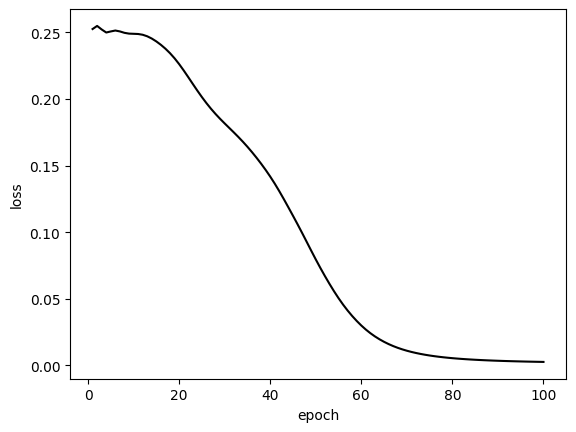

In [ ]:
# 학습 결과 시각화
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], color='black')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [ ]:
# 모델 예측
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 실제 입력

threshold = 0.5   # 임계치 0.5

y_pred = model.predict(x)
y = (y_pred >= threshold).astype(int).ravel()   # 예측한 출력

for i in range(4):
    print(f"x: {x[i]}   y: {y[i]}")   # 예측 결과 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
x: [0 0]   y: 0
x: [0 1]   y: 1
x: [1 0]   y: 1
x: [1 1]   y: 0


In [ ]:
# 예제 2.4 이미지 증강

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt
from PIL import Image

size of image: (1024, 1024) 



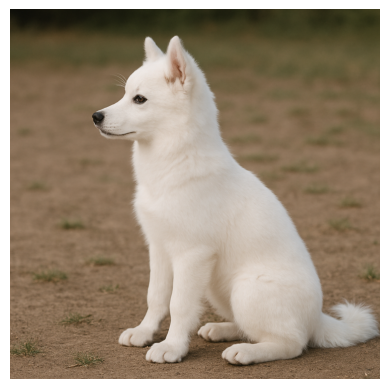

In [ ]:
# 원본 이미지 확인
file_path = "//content/drive/MyDrive/Datasets/강아지 사진1.png"

with Image.open(file_path) as img:
    print(f"size of image: {img.size} \n")

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
# 이미지 크기 조정
img = img.resize((160, 160))

In [ ]:
# 데이터 증강
image_augment = Sequential([
    RandomFlip("horizontal"),   # 수평 뒤집기
    RandomRotation(0.1),   # 회전
    RandomZoom(0.3)   # 확대
])

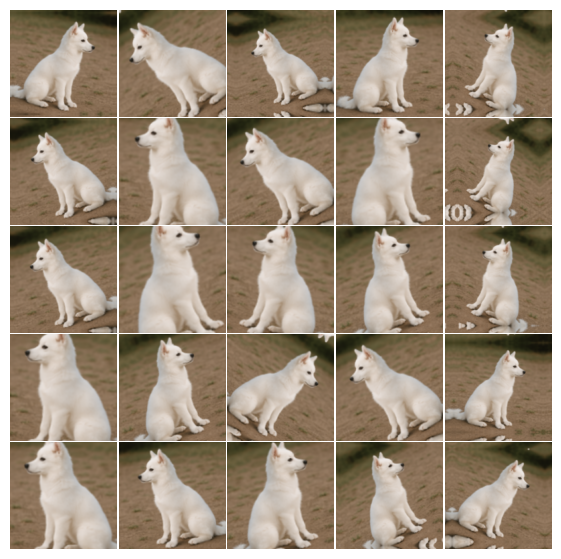

In [ ]:
# 데이터 증강 시각화
plt.figure(figsize=(7, 7))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(25):
    augmented_image = image_augment(tf.expand_dims(img, 0))   # 배치 차원 추가
                                     # (batch_size, height, width, channels)
    plt.subplot(5, 5, i + 1)
    plt.imshow(augmented_image[0] / 255)
    plt.axis("off")

plt.show()